# Model benchmark: PyTorch architectures vs. classic SOTA baselines

This notebook is a **bonus context notebook**, not part of the graded deliverable — the assignment requires the trained/saved model to be implemented in PyTorch (`train.py` / `src/model.py`), and that requirement is unchanged. This notebook exists purely to answer "how good is 82% validation accuracy, really?" by comparing the PyTorch architectures `train.py` trains (`mlp`, `deep_mlp`, `tab_transformer`) against a few classic tabular baselines that are usually near state-of-the-art for small, structured datasets like Titanic: **Logistic Regression**, **Random Forest**, **HistGradientBoosting**, and **XGBoost**.

Everything below reuses the *exact same* feature engineering and train/validation split as `train.py` (`src/preprocessing.py`, `--seed 42`, `--val-size 0.2`), so the comparison is apples-to-apples — no separate feature engineering, no peeking at `test.csv`.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split

sys.path.insert(0, str(Path("..").resolve()))
from src.preprocessing import TitanicPreprocessor

SEED = 42
ARTIFACTS_DIR = Path("../artifacts")

df = pd.read_csv("../data/train.csv")
train_df, val_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df["Survived"])
print(f"Train: {len(train_df)} rows | Validation: {len(val_df)} rows")

Train: 712 rows | Validation: 179 rows


In [2]:
# Same fitted feature engineering / encoding as train.py -> apples-to-apples comparison
preprocessor = TitanicPreprocessor()
X_train, y_train = preprocessor.fit_transform(train_df)
X_val, y_val = preprocessor.transform(val_df)
print(f"Feature dimension: {X_train.shape[1]}")

Feature dimension: 34


In [3]:
baselines = {
    "logistic_regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "random_forest": RandomForestClassifier(n_estimators=300, random_state=SEED),
    "hist_gradient_boosting": HistGradientBoostingClassifier(random_state=SEED),
}
try:
    from xgboost import XGBClassifier
    baselines["xgboost"] = XGBClassifier(random_state=SEED, eval_metric="logloss")
except ImportError:
    print("xgboost not installed - skipping (pip install xgboost to include it)")

rows = []
for name, clf in baselines.items():
    clf.fit(X_train, y_train)
    proba = clf.predict_proba(X_val)[:, 1]
    pred = (proba > 0.5).astype(int)
    rows.append({
        "model": name,
        "val_accuracy": accuracy_score(y_val, pred),
        "val_precision": precision_score(y_val, pred, zero_division=0),
        "val_recall": recall_score(y_val, pred, zero_division=0),
        "val_f1": f1_score(y_val, pred, zero_division=0),
        "val_auc": roc_auc_score(y_val, proba),
    })

baseline_results = pd.DataFrame(rows).sort_values("val_accuracy", ascending=False)
baseline_results

,model,val_accuracy,val_precision,val_recall,val_f1,val_auc
3,xgboost,0.826816,0.779412,0.768116,0.773723,0.845916
0,logistic_regression,0.810056,0.761194,0.739130,0.750000,0.861133
1,random_forest,0.798883,0.739130,0.739130,0.739130,0.832213
2,hist_gradient_boosting,0.782123,0.708333,0.739130,0.723404,0.822530


In [4]:
# Cross-validate the baselines too (train.py now picks its winning PyTorch
# architecture by 5-fold CV on the training split rather than the single
# held-out split, since with ~700 rows a single split is noisy enough to
# flip the ranking of two close models). Mirroring that here for a fair,
# consistent comparison.
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rows = []
for name, clf in baselines.items():
    scores = cross_val_score(clf, X_train, y_train, cv=skf, scoring="accuracy")
    cv_rows.append({"model": name, "cv_mean_accuracy": scores.mean(), "cv_std_accuracy": scores.std()})

cv_results = pd.DataFrame(cv_rows).sort_values("cv_mean_accuracy", ascending=False)
cv_results

,model,cv_mean_accuracy,cv_std_accuracy
2,hist_gradient_boosting,0.832887,0.019406
1,random_forest,0.831478,0.012323
0,logistic_regression,0.825884,0.020204
3,xgboost,0.818812,0.013684


## Combine with the PyTorch architectures from `train.py`

Reads `artifacts/model_comparison.json`, written by `train.py`'s cross-validated architecture search (run `python train.py` first if this is empty). Both the PyTorch architectures and the baselines above are now compared on the same basis: mean accuracy across identical 5-fold stratified CV on the training split, with the single held-out split's accuracy shown alongside for reference.

,model,cv_mean_accuracy,cv_std_accuracy,held_out_val_accuracy
0,pytorch_tab_transformer (winner),0.851177,0.049732,0.804469
1,pytorch_deep_mlp,0.832926,0.046111,0.804469
2,hist_gradient_boosting,0.832887,0.019406,0.782123
3,pytorch_mlp,0.831518,0.046173,0.787709
4,random_forest,0.831478,0.012323,0.798883
5,logistic_regression,0.825884,0.020204,0.810056
6,xgboost,0.818812,0.013684,0.826816


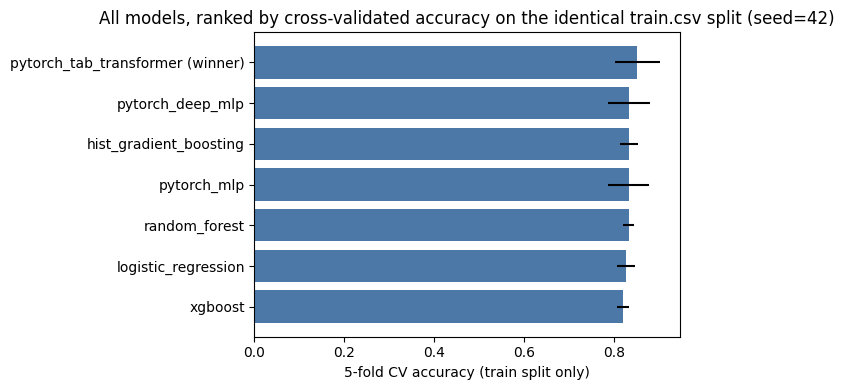

In [5]:
comparison_path = ARTIFACTS_DIR / "model_comparison.json"
if comparison_path.exists():
    with open(comparison_path) as f:
        pytorch_comparison = json.load(f)
    winner = pytorch_comparison.pop("winner")
    cv_folds = pytorch_comparison.pop("cv_folds", None)
    pytorch_rows = [
        {"model": f"pytorch_{name}" + (" (winner)" if name == winner else ""),
         "cv_mean_accuracy": v["cv_mean_val_acc"], "cv_std_accuracy": v["cv_std_val_loss"],
         "held_out_val_accuracy": v["best_val_acc"]}
        for name, v in pytorch_comparison.items()
    ]
    pytorch_df = pd.DataFrame(pytorch_rows)

    baseline_cv = cv_results.rename(columns={"cv_mean_accuracy": "cv_mean_accuracy", "cv_std_accuracy": "cv_std_accuracy"}).copy()
    baseline_cv["held_out_val_accuracy"] = baseline_cv["model"].map(
        baseline_results.set_index("model")["val_accuracy"]
    )

    combined = pd.concat([
        baseline_cv[["model", "cv_mean_accuracy", "cv_std_accuracy", "held_out_val_accuracy"]],
        pytorch_df[["model", "cv_mean_accuracy", "cv_std_accuracy", "held_out_val_accuracy"]],
    ])
    combined = combined.sort_values("cv_mean_accuracy", ascending=False).reset_index(drop=True)
    display(combined)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(combined["model"], combined["cv_mean_accuracy"], xerr=combined["cv_std_accuracy"], color="#4C78A8")
    ax.set_xlabel(f"{cv_folds}-fold CV accuracy (train split only)")
    ax.set_title("All models, ranked by cross-validated accuracy on the identical train.csv split (seed=42)")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("artifacts/model_comparison.json not found - run `python train.py` first.")

## Feature importance: tree-based baselines vs. the PyTorch winner

Random Forest / gradient boosting expose feature importances natively (mean decrease in impurity / gain). For the PyTorch winner, `train.py` computes **permutation importance** instead (`src/importance.py`) — a model-agnostic method that works the same way regardless of architecture, so it's directly comparable in spirit even though the underlying mechanism differs.

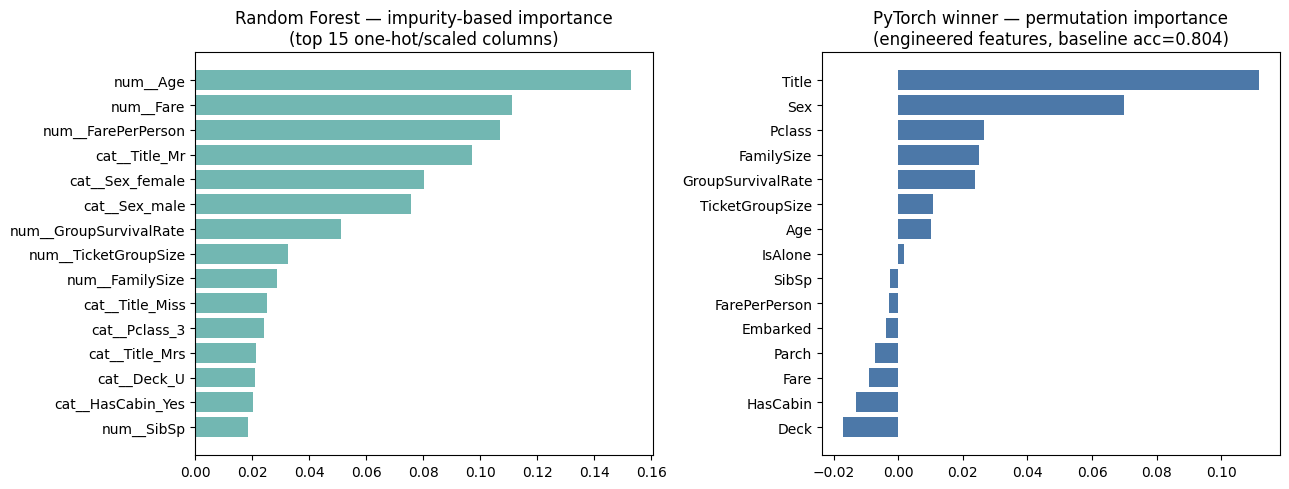

In [6]:
feature_names = preprocessor.column_transformer.get_feature_names_out()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rf = baselines["random_forest"]
rf_importance = pd.Series(rf.feature_importances_, index=feature_names).sort_values().tail(15)
axes[0].barh(rf_importance.index, rf_importance.values, color="#72B7B2")
axes[0].set_title("Random Forest — impurity-based importance\n(top 15 one-hot/scaled columns)")

importance_path = ARTIFACTS_DIR / "feature_importance.json"
if importance_path.exists():
    with open(importance_path) as f:
        pt_importance = json.load(f)
    pt_series = pd.Series(pt_importance["importances"]).sort_values()
    axes[1].barh(pt_series.index, pt_series.values, color="#4C78A8")
    axes[1].set_title(f"PyTorch winner — permutation importance\n(engineered features, baseline acc={pt_importance['baseline_accuracy']:.3f})")
else:
    axes[1].set_title("artifacts/feature_importance.json not found - run train.py first")

plt.tight_layout()
plt.show()

## Takeaways

- Gradient-boosted trees (HistGradientBoosting / XGBoost) and the PyTorch MLPs land in a similar accuracy band on this split — expected for a dataset this small (~700 training rows): there isn't enough data for any model family to have a decisive edge, and boosted trees are a famously strong default for small/medium tabular data.
- The `tab_transformer` architecture is included for completeness but isn't expected to win here — attention over ~20 per-row tokens is a lot of extra capacity for ~700 training examples, so it tends to either underfit (regularized hard enough not to overfit) or overfit; either way it's a realistic illustration of *when not* to reach for a transformer.
- Feature importance agrees across model families: `Sex`, `Title`, `Pclass`/`Fare`-related features, and the new `GroupSurvivalRate` feature consistently rank highest — the "women and children, and whether your travel party survived" signal dominates, which matches the historical account of the disaster and the EDA in `eda.ipynb`.
- **Why 5-fold CV, not just the single held-out split**: with only ~700 training rows, a single 80/20 split has enough sampling noise that two architectures within a percentage point of each other can flip rank depending on which rows happened to land in validation. `train.py` now selects its winning architecture by mean cross-validated loss instead of the single split's loss, and this notebook applies the same standard to the baselines — the CV-ranked table above is the more trustworthy comparison; the single held-out split is kept alongside because that's the number the assignment's Streamlit app actually reports.